# Mutation EDA Report

## 분석 목적

현재 데이터의 변이 분포를 다시 확인하고, 이후 전처리와 모델링에서 사용할 수 있는 근거를 정리합니다.

## 분석 항목

1. 유전자별 WT 비율 분석
2. 암종별 Top Mutation 분석
3. 암종별 Top Gene 분석
4. Mutation 종류 빈도 분석
5. 샘플당 Mutation 개수 분석
6. 암종별 Mutation Signature, 대표 변이 조합 분석

## 데이터 가정

현재 `train.csv`는 TCGA/MAF 원본 long format이 아니라 `sample x gene` wide matrix입니다.
각 gene이 컬럼이고, 셀 값은 `WT` 또는 해당 gene의 mutation token입니다.


## 0. 데이터 로드와 공통 함수

In [1]:
from __future__ import annotations

import itertools
import os
from pathlib import Path
import re
import sys
import tempfile
from typing import Any

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib-member-b-eda'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'requirements.txt').exists() and (path / 'experiments').exists():
            return path
    raise FileNotFoundError('저장소 루트를 찾지 못했습니다. 저장소 루트에서 JupyterLab을 실행하세요.')


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TRAIN_PATH = ROOT / 'data' / 'raw' / 'train.csv'
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)

ID_COLUMN = 'ID'
TARGET_COLUMN = 'SUBCLASS'
WT_VALUE = 'WT'
GENE_COLUMNS = [column for column in train_df.columns if column not in {ID_COLUMN, TARGET_COLUMN}]


def normalize_token(value: Any) -> str:
    if pd.isna(value):
        return WT_VALUE
    token = str(value).strip()
    return token if token else WT_VALUE


normalized_gene_df = train_df[GENE_COLUMNS].apply(lambda column: column.map(normalize_token))
mutation_mask = normalized_gene_df.ne(WT_VALUE)

print('project root:', ROOT)
print('train shape:', train_df.shape)
print('gene column count:', len(GENE_COLUMNS))
print('class count:', train_df[TARGET_COLUMN].nunique())
display(train_df[[ID_COLUMN, TARGET_COLUMN]].head())


project root: /Users/admin/Documents/FinalProject/OZ_fianl_hackaton
train shape: (6201, 4386)
gene column count: 4384
class count: 26


,ID,SUBCLASS
0,TRAIN_0000,KIPAN
1,TRAIN_0001,SARC
2,TRAIN_0002,SKCM
3,TRAIN_0003,KIRC
4,TRAIN_0004,GBMLGG


## 1. 유전자별 WT 비율 분석

각 gene이 얼마나 자주 `WT`로 나타나는지 확인합니다.
WT 비율이 낮다는 것은 해당 gene에서 mutation이 자주 관찰된다는 뜻입니다.


,mutation_count,mutation_ratio,wt_count,wt_ratio
TP53,1770,0.285438,4431,0.714562
PIK3CA,686,0.110627,5515,0.889373
RYR2,643,0.103693,5558,0.896307
SYNE1,642,0.103532,5559,0.896468
PCLO,593,0.095630,5608,0.904370
RYR1,473,0.076278,5728,0.923722
SPTA1,461,0.074343,5740,0.925657
KMT2D,451,0.072730,5750,0.927270
IDH1,441,0.071118,5760,0.928882
BRAF,438,0.070634,5763,0.929366


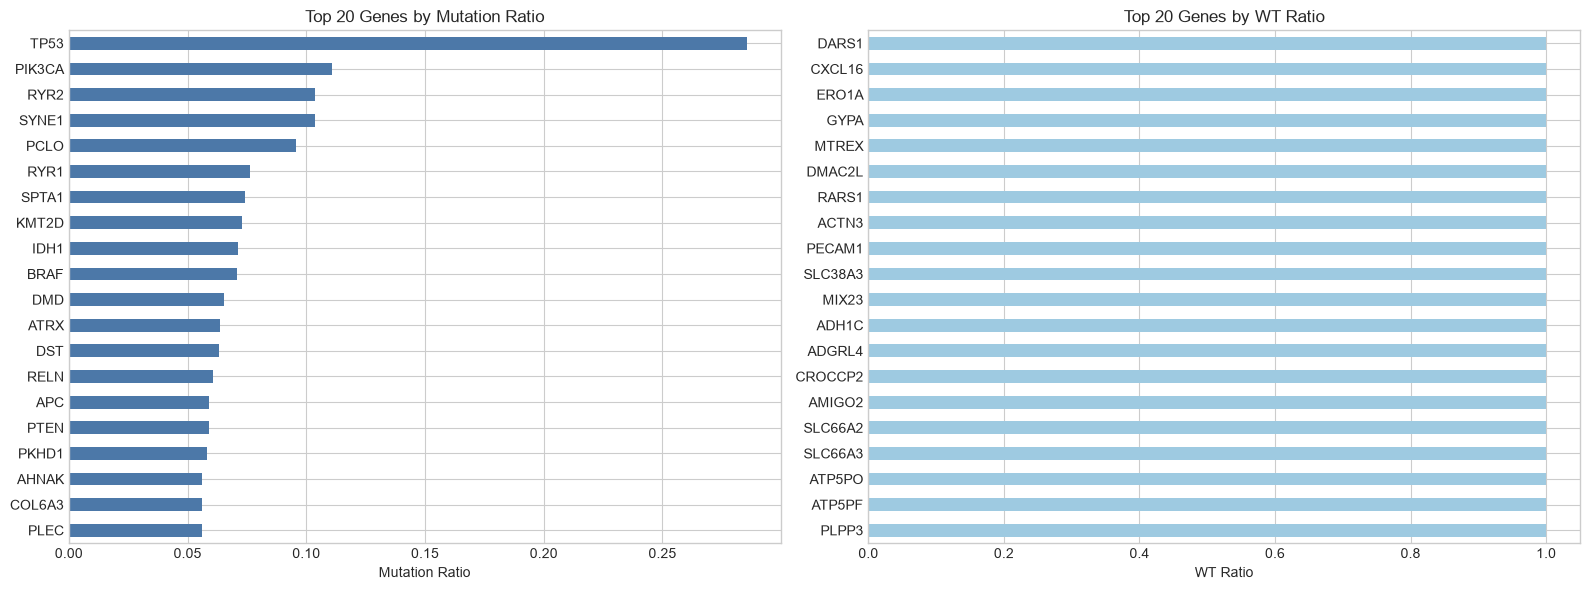

In [2]:
gene_summary = pd.DataFrame({
    'mutation_count': mutation_mask.sum(axis=0),
    'mutation_ratio': mutation_mask.mean(axis=0),
})
gene_summary['wt_count'] = len(train_df) - gene_summary['mutation_count']
gene_summary['wt_ratio'] = 1.0 - gene_summary['mutation_ratio']
gene_summary = gene_summary.sort_values('wt_ratio')

display(gene_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gene_summary.head(20).sort_values('mutation_ratio').plot(
    kind='barh', y='mutation_ratio', ax=axes[0], color='#4C78A8', legend=False,
)
axes[0].set_title('Top 20 Genes by Mutation Ratio')
axes[0].set_xlabel('Mutation Ratio')

most_wt_genes = gene_summary.tail(20).sort_values('wt_ratio')
most_wt_genes.plot(
    kind='barh', y='wt_ratio', ax=axes[1], color='#9ECAE1', legend=False,
)
axes[1].set_title('Top 20 Genes by WT Ratio')
axes[1].set_xlabel('WT Ratio')

plt.tight_layout()
plt.show()


## 2. 암종별 Top Mutation 분석

`gene + mutation token` 조합을 하나의 mutation event로 보고, 암종별로 자주 나타나는 구체적인 변이를 확인합니다.


/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_65040/1920851185.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(dropna=True)


mutation event rows: 218893


,SUBCLASS,gene,mutation,event_count
2075,ACC,SOWAHC,L42L,24
405,ACC,CMPK2,C153C,20
1169,ACC,LRIG1,L26V L24V,19
1398,ACC,NFKB2,P423P,16
2230,ACC,TM7SF2,P52P,16
7387,BLCA,PIK3CA,E545K,9
4894,BLCA,FGFR3,S249C,6
9250,BLCA,TP53,R248Q,6
8181,BLCA,RXRA,S427F,5
7386,BLCA,PIK3CA,E542K,4


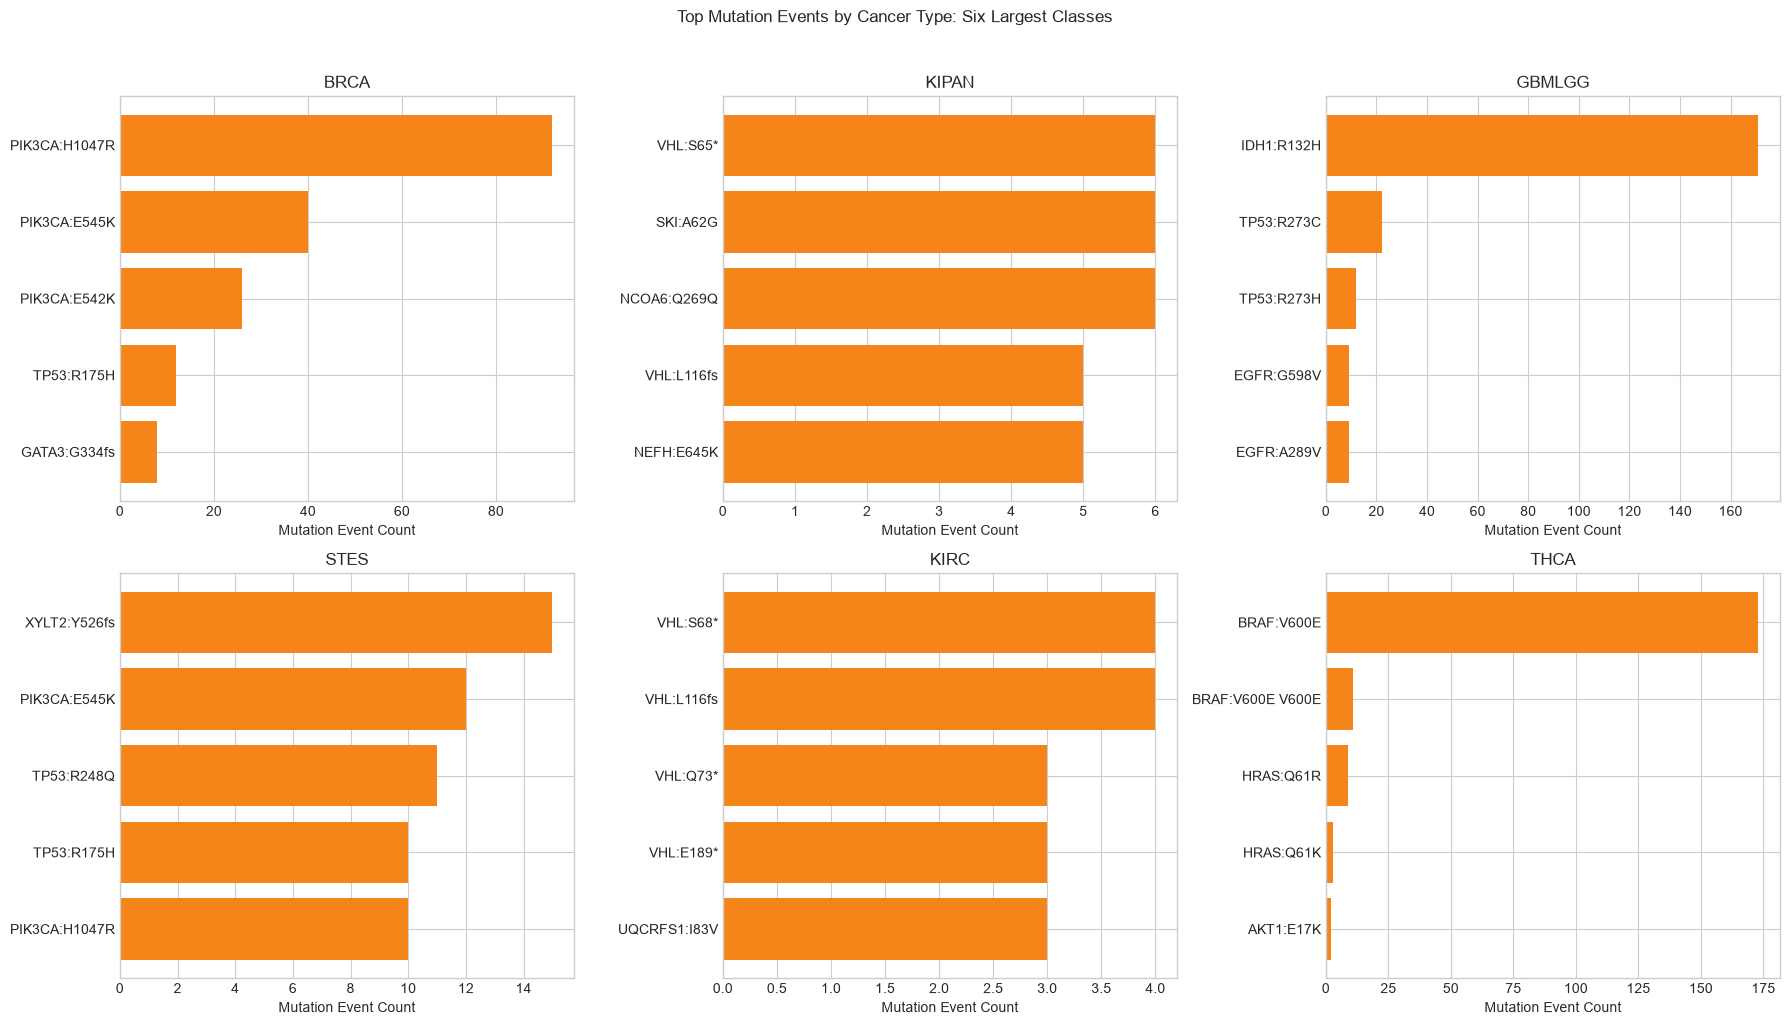

In [3]:
# WT가 아닌 셀만 long 형태로 펼칩니다.
mutation_long = (
    normalized_gene_df.where(mutation_mask)
    .stack(dropna=True)
    .rename('mutation')
    .reset_index()
    .rename(columns={'level_0': 'row_index', 'level_1': 'gene'})
)
mutation_long[TARGET_COLUMN] = train_df.loc[mutation_long['row_index'], TARGET_COLUMN].to_numpy()
mutation_long['mutation_event'] = mutation_long['gene'] + ':' + mutation_long['mutation']

print('mutation event rows:', len(mutation_long))

top_mutation_by_class = (
    mutation_long.groupby([TARGET_COLUMN, 'gene', 'mutation'], as_index=False)
    .size()
    .rename(columns={'size': 'event_count'})
    .sort_values([TARGET_COLUMN, 'event_count'], ascending=[True, False])
)
top_mutation_table = top_mutation_by_class.groupby(TARGET_COLUMN, group_keys=False).head(5)
display(top_mutation_table.head(30))

# 샘플 수가 많은 상위 6개 암종만 bar chart로 보여줍니다.
top_classes_for_plot = train_df[TARGET_COLUMN].value_counts().head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, cancer_type in zip(axes.ravel(), top_classes_for_plot):
    plot_data = top_mutation_by_class[top_mutation_by_class[TARGET_COLUMN] == cancer_type].head(5).copy()
    plot_data['label'] = plot_data['gene'] + ':' + plot_data['mutation'].str.slice(0, 18)
    plot_data = plot_data.sort_values('event_count')
    axis.barh(plot_data['label'], plot_data['event_count'], color='#F58518')
    axis.set_title(cancer_type)
    axis.set_xlabel('Mutation Event Count')

plt.suptitle('Top Mutation Events by Cancer Type: Six Largest Classes', y=1.02)
plt.tight_layout()
plt.show()


## 3. 암종별 Top Gene 분석

이번에는 구체적인 mutation token이 아니라, 암종별로 변이가 관찰된 gene 자체를 비교합니다.


,SUBCLASS,gene,mutated_sample_count
0,ACC,PLEC,38
1,ACC,LRIG1,25
2,ACC,SOWAHC,24
3,ACC,CMPK2,20
4,ACC,NFKB2,18
5,BLCA,TP53,55
6,BLCA,KMT2D,31
7,BLCA,PIK3CA,23
8,BLCA,SYNE1,22
9,BLCA,SPTAN1,19


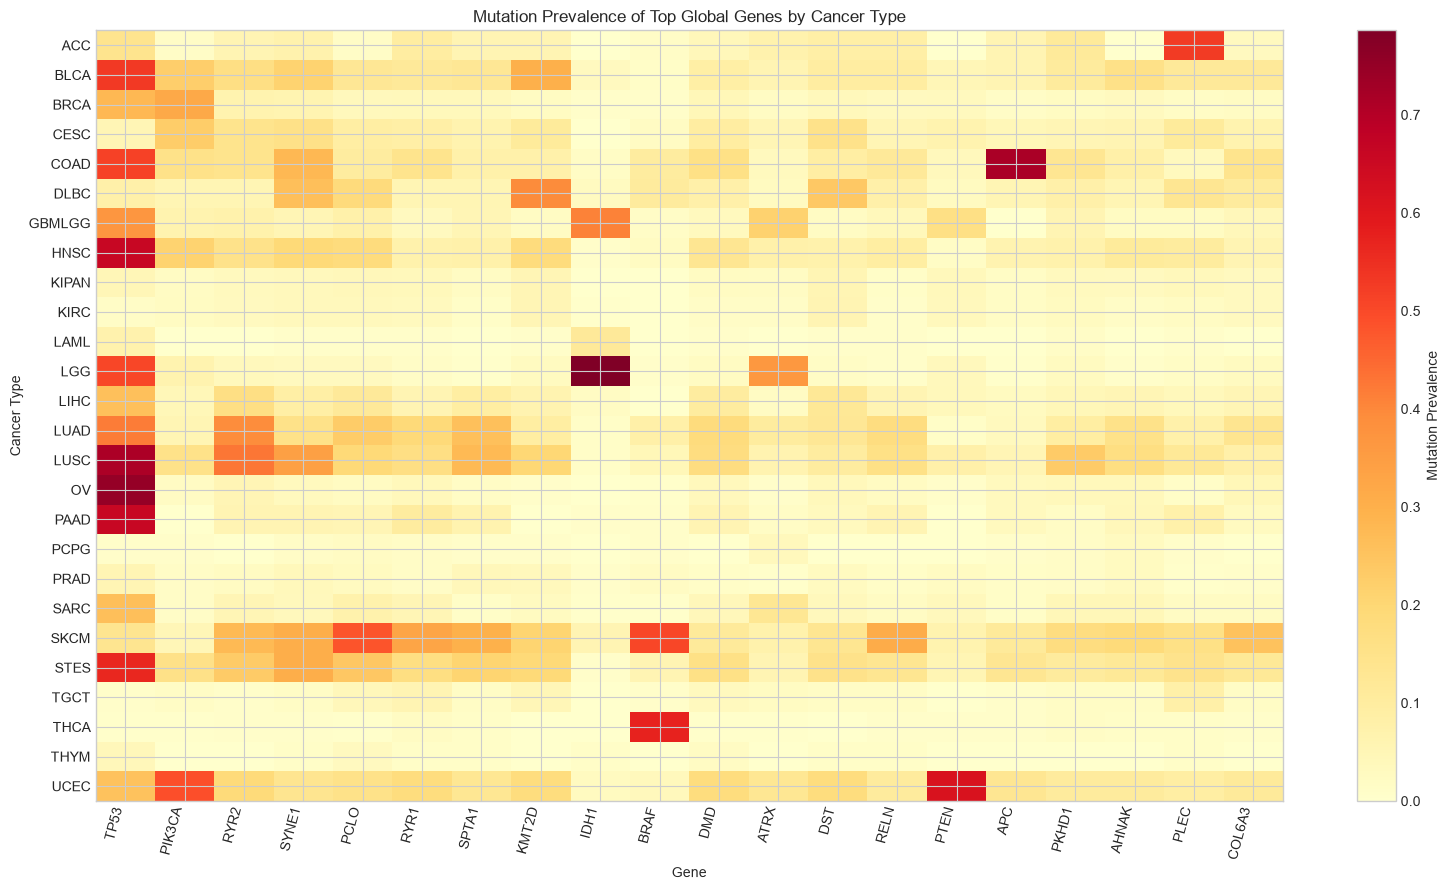

In [4]:
gene_counts_by_class = mutation_mask.assign(**{TARGET_COLUMN: train_df[TARGET_COLUMN].to_numpy()}).groupby(TARGET_COLUMN)[GENE_COLUMNS].sum()

top_gene_rows = []
for cancer_type, row in gene_counts_by_class.iterrows():
    for gene, count in row.sort_values(ascending=False).head(5).items():
        top_gene_rows.append({TARGET_COLUMN: cancer_type, 'gene': gene, 'mutated_sample_count': int(count)})

top_gene_table = pd.DataFrame(top_gene_rows)
display(top_gene_table.head(30))

# 전체 암종에서 자주 등장하는 gene을 기준으로 heatmap을 만듭니다.
top_global_genes = mutation_mask.sum(axis=0).sort_values(ascending=False).head(20).index.tolist()
heatmap_data = gene_counts_by_class[top_global_genes].div(train_df[TARGET_COLUMN].value_counts(), axis=0)
heatmap_data = heatmap_data.sort_index()

fig, ax = plt.subplots(figsize=(16, 9))
image = ax.imshow(heatmap_data.to_numpy(), aspect='auto', cmap='YlOrRd')
ax.set_title('Mutation Prevalence of Top Global Genes by Cancer Type')
ax.set_xlabel('Gene')
ax.set_ylabel('Cancer Type')
ax.set_xticks(range(len(top_global_genes)))
ax.set_xticklabels(top_global_genes, rotation=75, ha='right')
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
fig.colorbar(image, ax=ax, label='Mutation Prevalence')
plt.tight_layout()
plt.show()


## 4. Mutation 종류 빈도 분석

현재 데이터에는 `Variant_Classification` 컬럼이 없기 때문에, mutation token 문자열의 패턴을 이용해 실용적인 범주를 만듭니다.
이 결과는 원본 MAF의 공식 Variant_Classification과 동일하지 않을 수 있습니다.


,mutation_type,count
0,Missense_like,178415
1,Other,18112
2,Nonsense,12821
3,Frameshift,9542
4,Indel,3


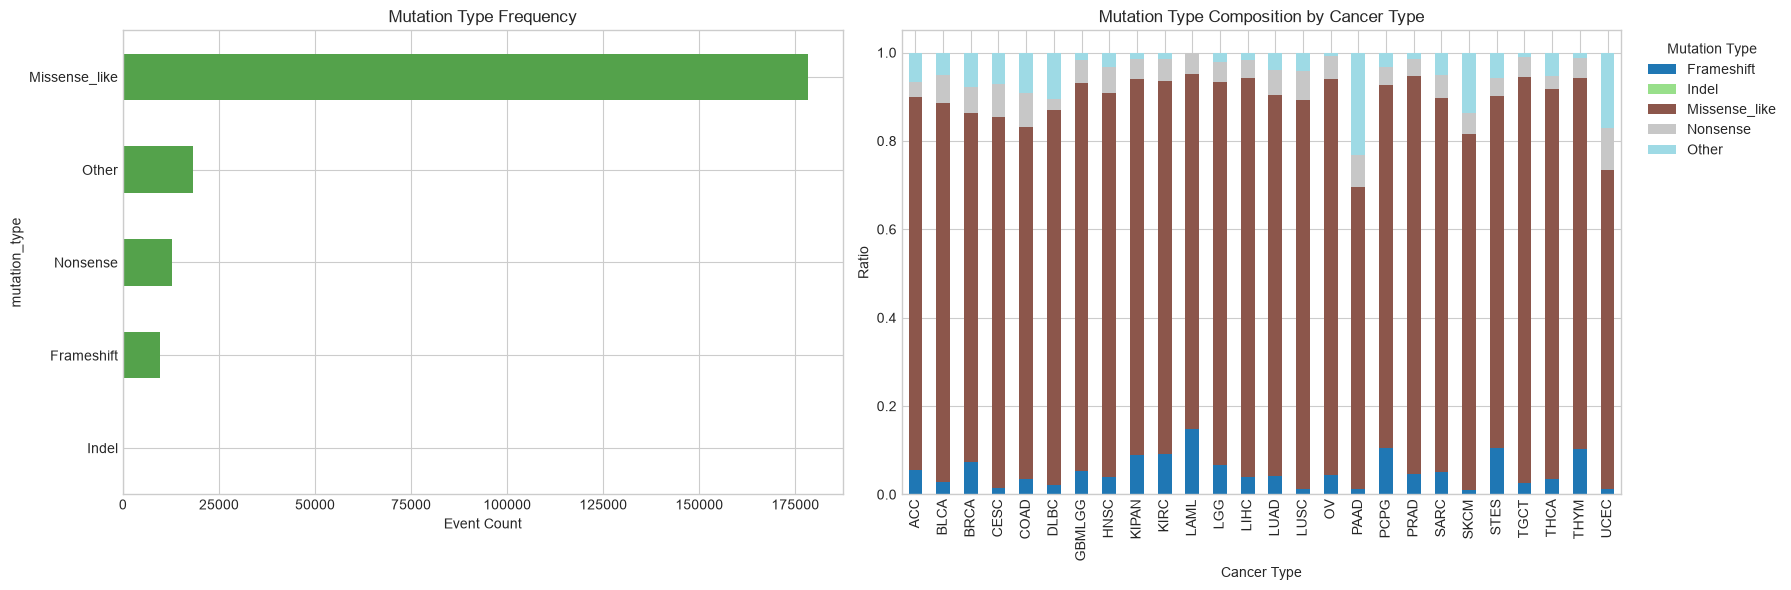

In [5]:
def classify_mutation_token(token: str) -> str:
    token_lower = token.lower()
    if token == WT_VALUE:
        return 'WT'
    if re.search(r'fs|frameshift', token_lower):
        return 'Frameshift'
    if re.search(r'splice', token_lower):
        return 'Splice'
    if re.search(r'\*|stop|ter', token_lower):
        return 'Nonsense'
    if re.search(r'del|ins|dup', token_lower):
        return 'Indel'
    if re.search(r'p\.[a-z]\d+[a-z]', token_lower) or re.search(r'^[a-z]\d+[a-z]$', token_lower):
        return 'Missense_like'
    return 'Other'


mutation_long['mutation_type'] = mutation_long['mutation'].map(classify_mutation_token)
mutation_type_counts = mutation_long['mutation_type'].value_counts()
display(mutation_type_counts.rename_axis('mutation_type').reset_index(name='count'))

class_type_counts = pd.crosstab(mutation_long[TARGET_COLUMN], mutation_long['mutation_type'])
class_type_ratio = class_type_counts.div(class_type_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
mutation_type_counts.sort_values().plot(kind='barh', ax=axes[0], color='#54A24B')
axes[0].set_title('Mutation Type Frequency')
axes[0].set_xlabel('Event Count')

class_type_ratio.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20')
axes[1].set_title('Mutation Type Composition by Cancer Type')
axes[1].set_xlabel('Cancer Type')
axes[1].set_ylabel('Ratio')
axes[1].legend(title='Mutation Type', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


## 5. 샘플당 Mutation 개수 분석

샘플별 mutation gene 수를 계산해 암종별 mutation burden 분포를 확인합니다.


,count,mean,median,max
SUBCLASS,,,,
SKCM,276,132.532609,85.5,2025
LUSC,178,69.528090,57.0,579
BLCA,104,70.490385,54.0,382
STES,379,81.841689,41.0,1076
LUAD,184,58.043478,40.5,285
HNSC,223,40.569507,31.0,386
DLBC,38,67.421053,30.0,704
LIHC,158,31.335443,25.0,286
ACC,72,39.430556,24.0,396


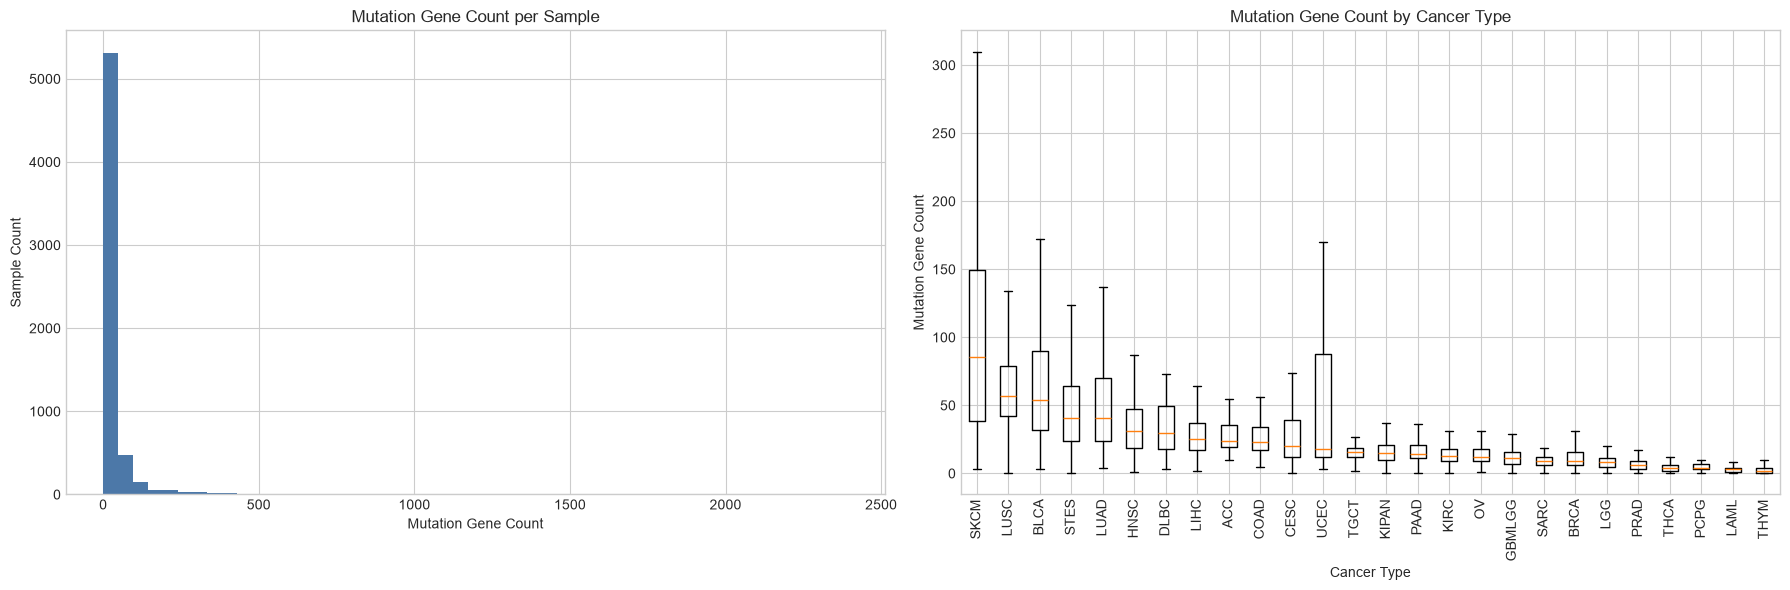

In [6]:
sample_mutation_counts = mutation_mask.sum(axis=1).rename('mutation_gene_count')
sample_mutation_counts = pd.DataFrame({
    TARGET_COLUMN: train_df[TARGET_COLUMN].to_numpy(),
    'mutation_gene_count': sample_mutation_counts.to_numpy(),
})

sample_summary_by_class = (
    sample_mutation_counts.groupby(TARGET_COLUMN)['mutation_gene_count']
    .agg(['count', 'mean', 'median', 'max'])
    .sort_values('median', ascending=False)
)
display(sample_summary_by_class)

ordered_classes = sample_summary_by_class.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].hist(sample_mutation_counts['mutation_gene_count'], bins=50, color='#4C78A8')
axes[0].set_title('Mutation Gene Count per Sample')
axes[0].set_xlabel('Mutation Gene Count')
axes[0].set_ylabel('Sample Count')

box_data = [sample_mutation_counts.loc[sample_mutation_counts[TARGET_COLUMN] == cancer, 'mutation_gene_count'] for cancer in ordered_classes]
axes[1].boxplot(box_data, tick_labels=ordered_classes, showfliers=False)
axes[1].set_title('Mutation Gene Count by Cancer Type')
axes[1].set_xlabel('Cancer Type')
axes[1].set_ylabel('Mutation Gene Count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


## 6. 암종별 Mutation Signature 분석

여기서는 복잡한 signature 모델 대신, 암종별로 함께 변이되는 gene pair를 대표 조합으로 정의합니다.
각 암종에서 mutated sample 수가 많은 상위 gene 12개를 대상으로 pair 공동 발생을 계산합니다.


,SUBCLASS,gene_a,gene_b,pair_label,co_mutated_sample_count
0,ACC,PLEC,LRIG1,PLEC + LRIG1,12
1,ACC,PLEC,SOWAHC,PLEC + SOWAHC,12
2,ACC,PLEC,CMPK2,PLEC + CMPK2,11
66,BLCA,TP53,KMT2D,TP53 + KMT2D,16
67,BLCA,TP53,PIK3CA,TP53 + PIK3CA,16
68,BLCA,TP53,SYNE1,TP53 + SYNE1,14
131,BRCA,PIK3CA,TP53,PIK3CA + TP53,50
132,BRCA,PIK3CA,CDH1,PIK3CA + CDH1,35
134,BRCA,PIK3CA,MAP3K1,PIK3CA + MAP3K1,27
216,CESC,SYNE1,PCLO,SYNE1 + PCLO,10


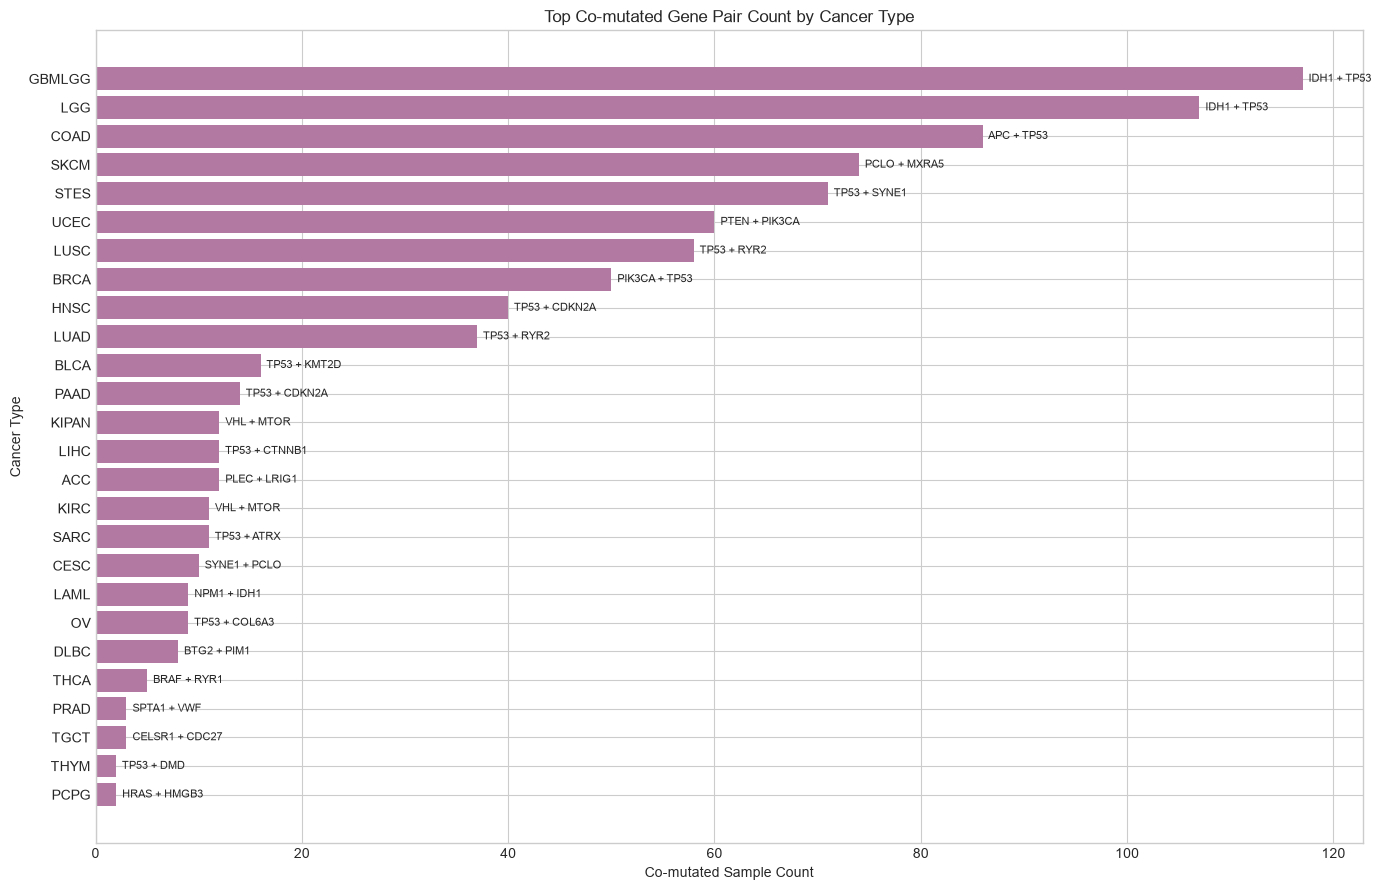

In [7]:
signature_rows = []

for cancer_type, class_frame in train_df.groupby(TARGET_COLUMN):
    class_mask = mutation_mask.loc[class_frame.index]
    top_genes = class_mask.sum(axis=0).sort_values(ascending=False).head(12).index.tolist()

    for gene_a, gene_b in itertools.combinations(top_genes, 2):
        both_count = int((class_mask[gene_a] & class_mask[gene_b]).sum())
        if both_count == 0:
            continue
        signature_rows.append({
            TARGET_COLUMN: cancer_type,
            'gene_a': gene_a,
            'gene_b': gene_b,
            'pair_label': f'{gene_a} + {gene_b}',
            'co_mutated_sample_count': both_count,
        })

signature_table = pd.DataFrame(signature_rows).sort_values(
    [TARGET_COLUMN, 'co_mutated_sample_count'], ascending=[True, False]
)
top_signature_table = signature_table.groupby(TARGET_COLUMN, group_keys=False).head(3)
display(top_signature_table.head(50))

# 암종별 1위 pair를 한눈에 비교합니다.
top_signature_per_class = top_signature_table.groupby(TARGET_COLUMN, as_index=False).head(1).sort_values('co_mutated_sample_count')
fig, ax = plt.subplots(figsize=(14, 9))
ax.barh(top_signature_per_class[TARGET_COLUMN], top_signature_per_class['co_mutated_sample_count'], color='#B279A2')
ax.set_title('Top Co-mutated Gene Pair Count by Cancer Type')
ax.set_xlabel('Co-mutated Sample Count')
ax.set_ylabel('Cancer Type')

for index, row in enumerate(top_signature_per_class.itertuples()):
    ax.text(row.co_mutated_sample_count, index, f'  {row.pair_label}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


## Takeaways 작성 기준

실행 후 아래 질문을 기준으로 결과를 정리합니다.

- 어떤 gene의 WT 비율이 가장 낮은가?
- 암종별로 공통 mutation event와 특이 mutation event가 구분되는가?
- 암종별 Top Gene 패턴이 얼마나 다른가?
- 특정 mutation type이 특정 암종에 집중되는가?
- mutation burden가 높은 암종과 낮은 암종은 어디인가?
- 암종별 대표 co-mutation pair가 반복적으로 나타나는가?

주의: 이 EDA 결과만으로 전처리나 모델 성능을 확정하지 않고, 후보 feature는 반드시 동일 benchmark에서 검증합니다.
